# Greek IDA2/IDA3 Intraday Price Forecasting — Full Model Comparison

Four models compared on identical data with Optuna hyperparameter optimization:
- **LSTM** — sequential processing of market history
- **MLP** — flattened lookback window, feed-forward
- **XGBoost** — tree-based ensemble, separate model per horizon
- **Linear Regression** — simple baseline

Features include ISP forecast revisions from ADMIE (published ~2h before each IDA auction).
Evaluation: MAE, RMSE, R², FSI (Forecast Skill Index vs naive persistence).

In [ ]:
!pip install optuna xgboost -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import itertools, random, os, time, warnings

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

# ── Reproducibility ──
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.2 MB/s eta 0:00:00
Device: cuda


## 1. Data Loading and Feature Engineering

In [ ]:
FILENAME = '/content/Final2026_with_ENTSOE.csv'

try:
    df = pd.read_csv(FILENAME, sep=',')
    if len(df.columns) == 1: df = pd.read_csv(FILENAME, sep=';')
except: df = pd.read_csv(FILENAME)

# Rename columns to internal names used throughout the notebook
df = df.rename(columns={
    'Day time': 'DELIVERY_MTU',
    'DAM price': 'DAM_MCP',
    'IDA1': 'MCP',
    'IDA2': 'MCP_IDA2',
    'IDA3': 'MCP_IDA3',
    'BM price': 'BM_IMBALANCE_PRICE',
    'BMmDAM price': 'BMmDAMMCP',
})

df['DELIVERY_MTU'] = pd.to_datetime(df['DELIVERY_MTU'])
df = df.sort_values('DELIVERY_MTU').reset_index(drop=True)

# Time features
df['hour']      = df['DELIVERY_MTU'].dt.hour
df['minute']    = df['DELIVERY_MTU'].dt.minute / 60.0
df['dayofweek'] = df['DELIVERY_MTU'].dt.dayofweek
df['ida3_available'] = df['MCP_IDA3'].notna().astype(float)

# Fill missing — use global ffill/bfill for multi-day gaps
df['MCP_IDA3']  = df['MCP_IDA3'].fillna(0.0)
df['MCP_IDA2']  = df['MCP_IDA2'].ffill().bfill().fillna(0.0)
df['MCP']       = df['MCP'].ffill().bfill().fillna(df['MCP_IDA2'])
df['DAM_MCP']   = df['DAM_MCP'].ffill().bfill()
df['BMmDAMMCP'] = df['BMmDAMMCP'].ffill().bfill().fillna(0.0)
df['BM_IMBALANCE_PRICE'] = df['BM_IMBALANCE_PRICE'].ffill().bfill().fillna(df['BM_IMBALANCE_PRICE'].median())
df['IDA_target'] = np.where(df['ida3_available'] == 1, df['MCP_IDA3'], df['MCP_IDA2'])
df['ISP2_RES']  = df['ISP2_RES'].ffill().bfill().fillna(df['ISP1_RES'])
df['ISP2_Load'] = df['ISP2_Load'].ffill().bfill().fillna(df['ISP1_Load'])

# ── ISP revision features ──
df['DA_RES'] = df['Wind_DA_forecast'] + df['Solar_DA_forecast']
is_ida3 = df['hour'] >= 12

# Latest available ISP (ISP2 for IDA2, ISP3 for IDA3 — no leakage)
df['latest_RES']  = np.where(is_ida3, df['ISP3_RES'], df['ISP2_RES'])
df['latest_Load'] = np.where(is_ida3, df['ISP3_Load'], df['ISP2_Load'])

# Revision features (delta from DA)
df['latest_RES_revision']  = df['latest_RES'] - df['DA_RES']
df['latest_Load_revision'] = df['latest_Load'] - df['SystemLoad_DA_forecast']
df['latest_net_load']      = df['latest_Load'] - df['latest_RES']
df['DA_net_load']          = df['SystemLoad_DA_forecast'] - df['DA_RES']
df['latest_net_load_revision'] = df['latest_net_load'] - df['DA_net_load']

# ISP2→ISP3 sequential revision (only for IDA3 rows)
df['RES_revision_ISP2_to_ISP3']  = np.where(is_ida3, df['ISP3_RES'] - df['ISP2_RES'], 0.0)
df['Load_revision_ISP2_to_ISP3'] = np.where(is_ida3, df['ISP3_Load'] - df['ISP2_Load'], 0.0)

# ── BM and momentum features ──
df['bm_roll_mean_4']  = df['BM_IMBALANCE_PRICE'].rolling(4, min_periods=1).mean()
df['bm_roll_std_4']   = df['BM_IMBALANCE_PRICE'].rolling(4, min_periods=1).std().fillna(0)
df['bm_roll_mean_12'] = df['BM_IMBALANCE_PRICE'].rolling(12, min_periods=1).mean()
df['ida_momentum']  = df['MCP_IDA2'].diff(4).fillna(0)
df['mcp_momentum']  = df['MCP'].diff(4).fillna(0)
df['bm_momentum']   = df['BM_IMBALANCE_PRICE'].diff(4).fillna(0)
df['bm_ida_spread']  = df['BM_IMBALANCE_PRICE'] - df['MCP_IDA2']
df['ida_roll_std_4'] = df['MCP_IDA2'].rolling(4, min_periods=1).std().fillna(0)

# ── Targets ──
for h_steps, h_name in [(4, '1h'), (8, '2h'), (12, '3h')]:
    df[f'IDA_target_{h_name}'] = df['IDA_target'].shift(-h_steps)
    df[f'ida3_at_{h_name}'] = (df['hour'].shift(-h_steps) >= 12).astype(float)

df = df.dropna(subset=['IDA_target_1h', 'IDA_target_2h', 'IDA_target_3h']).reset_index(drop=True)

# Date filter — full dataset Oct 2025 to Mar 2026
df = df[df['DELIVERY_MTU'] >= '2026-01-20'].copy().reset_index(drop=True)
df = df[df['DELIVERY_MTU'] <= '2026-03-12 23:45:00'].copy().reset_index(drop=True)

# ── Feature set ──
FEATURES = [
    # Prices
    'MCP', 'MCP_IDA2', 'DAM_MCP',
    # BM signal
    'BM_IMBALANCE_PRICE', 'bm_roll_mean_4', 'bm_roll_std_4', 'bm_roll_mean_12', 'bm_ida_spread',
    # Momentum
    'ida_momentum', 'mcp_momentum', 'bm_momentum',
    # Volatility
    'ida_roll_std_4',
    # DA context
    'SystemLoad_DA_forecast', 'Wind_DA_forecast', 'Solar_DA_forecast',
    # Auction flags
    'ida3_available', 'ida3_at_1h', 'ida3_at_2h', 'ida3_at_3h',
    # Time
    'hour', 'minute', 'dayofweek',
    # ISP raw (latest available, respecting info timeline)
    'latest_RES', 'latest_Load',
    # ISP revisions (delta from DA)
    'latest_RES_revision', 'latest_Load_revision', 'latest_net_load_revision', 'latest_net_load',
    # ISP2→ISP3 sequential change
    'RES_revision_ISP2_to_ISP3', 'Load_revision_ISP2_to_ISP3',
]

TARGETS = ['IDA_target_1h', 'IDA_target_2h', 'IDA_target_3h']
HORIZON = 3; BATCH = 64; TRAIN_RATIO = 0.8
split_idx = int(len(df) * TRAIN_RATIO)
N_FEAT = len(FEATURES)

# Check for any remaining NaNs in features
nan_check = df[FEATURES].isna().sum()
if nan_check.sum() > 0:
    print("WARNING: NaN in features:")
    print(nan_check[nan_check > 0])
    df[FEATURES] = df[FEATURES].ffill().bfill().fillna(0)
    print("Fixed with ffill/bfill/fillna(0)")

print(f"Dataset: {df.shape}, Features: {N_FEAT}")
print(f"Train: {split_idx}, Test: {len(df)-split_idx}")
print(f"Days: {df['DELIVERY_MTU'].dt.date.nunique()}")
print(f"Period: {df['DELIVERY_MTU'].min()} to {df['DELIVERY_MTU'].max()}")

Dataset: (4992, 45), Features: 30
Train: 3993, Test: 999
Days: 52
Period: 2026-01-20 00:00:00 to 2026-03-12 23:45:00


## 2. Evaluation Metrics

In [ ]:
def compute_metrics(y_true, y_pred, y_naive):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae_naive = mean_absolute_error(y_true, y_naive)
    fsi  = 1 - mae / mae_naive  # Forecast Skill Index
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'FSI': fsi}

def print_results_table(results_dict, naive_vals, acts, horizon_names=['1h','2h','3h']):
    print(f"  {'Model':<16}", end="")
    for h in horizon_names:
        print(f" {'MAE-'+h:>8} {'RMSE-'+h:>9} {'R2-'+h:>7} {'FSI-'+h:>7}", end="")
    print()
    print(f"  {'-'*110}")
    for name, preds in results_dict.items():
        print(f"  {name:<16}", end="")
        for h in range(len(horizon_names)):
            m = compute_metrics(acts[:, h], preds[:, h], naive_vals)
            print(f" {m['MAE']:>8.2f} {m['RMSE']:>9.2f} {m['R2']:>7.3f} {m['FSI']:>+6.1f}%", end="")
        print()

print("Metrics ready: MAE, RMSE, R², FSI")

Metrics ready: MAE, RMSE, R², FSI


## 3. Data Scaling and Datasets

In [ ]:
# Scale features and targets
scaler_X = MinMaxScaler()
data_X = df[FEATURES].values.astype(np.float32)
scaler_X.fit(data_X[:split_idx])
data_X_sc = scaler_X.transform(data_X)

scaler_y = MinMaxScaler()
all_tgt = df[TARGETS].values.astype(np.float32)
scaler_y.fit(all_tgt[:split_idx].reshape(-1, 1))
tgt_sc = np.zeros((len(df), HORIZON), dtype=np.float32)
for h in range(HORIZON):
    tgt_sc[:, h] = scaler_y.transform(df[TARGETS[h]].values.astype(np.float32).reshape(-1,1)).flatten()

# PyTorch datasets
class LSTMDataset(Dataset):
    def __init__(self, X, y, lb):
        self.X, self.y, self.lb = X, y, lb
    def __len__(self): return len(self.X) - self.lb
    def __getitem__(self, i):
        return (torch.tensor(self.X[i:i+self.lb], dtype=torch.float32),
                torch.tensor(self.y[i+self.lb], dtype=torch.float32))

class MLPDataset(Dataset):
    def __init__(self, X, y, lb):
        self.X, self.y, self.lb = X, y, lb
    def __len__(self): return len(self.X) - self.lb
    def __getitem__(self, i):
        return (torch.tensor(self.X[i:i+self.lb].flatten(), dtype=torch.float32),
                torch.tensor(self.y[i+self.lb], dtype=torch.float32))

print("Scaling and datasets ready")

Scaling and datasets ready


## 4. Model Definitions

In [ ]:
class PointLSTM(nn.Module):
    def __init__(self, n_feat, hidden, layers, horizon, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, layers, batch_first=True,
                            dropout=dropout if layers > 1 else 0.0)
        self.fc = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(hidden // 2, horizon))
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

class PointMLP(nn.Module):
    def __init__(self, input_dim, hidden, n_layers, horizon, dropout=0.2):
        super().__init__()
        layers = []
        prev = input_dim
        for _ in range(n_layers):
            layers += [nn.Linear(prev, hidden), nn.ReLU(), nn.Dropout(dropout)]
            prev = hidden
        layers.append(nn.Linear(hidden, horizon))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

def train_nn(model, ld_tr, ld_te, epochs, lr, label="", verbose=True):
    model = model.to(device)
    crit = nn.L1Loss()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=8, factor=0.5)
    best_test = float('inf'); best_state = None
    for ep in range(1, epochs+1):
        model.train(); tl = 0
        for X, y in ld_tr:
            X, y = X.to(device), y.to(device)
            opt.zero_grad(); loss = crit(model(X), y); loss.backward(); opt.step()
            tl += loss.item() * X.size(0)
        tl /= len(ld_tr.dataset)
        model.eval(); vl = 0
        with torch.no_grad():
            for X, y in ld_te:
                X, y = X.to(device), y.to(device)
                vl += crit(model(X), y).item() * X.size(0)
        vl /= len(ld_te.dataset)
        sched.step(vl)
        if vl < best_test:
            best_test = vl
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if verbose and (ep % 30 == 0 or ep == 1):
            print(f"  [{label}] {ep:3d}/{epochs} | train: {tl:.6f} | test: {vl:.6f}")
    model.load_state_dict(best_state)
    if verbose: print(f"  [{label}] Best: {best_test:.6f}")
    return best_test

def eval_nn(model, ds_te, scaler_y, horizon):
    model.eval()
    preds_all, acts_all = [], []
    with torch.no_grad():
        for X, y in DataLoader(ds_te, batch_size=256, shuffle=False):
            preds_all.append(model(X.to(device)).cpu().numpy())
            acts_all.append(y.numpy())
    preds = np.concatenate(preds_all); acts = np.concatenate(acts_all)
    p_inv = np.zeros_like(preds); a_inv = np.zeros_like(acts)
    for h in range(horizon):
        p_inv[:, h] = scaler_y.inverse_transform(preds[:, h].reshape(-1,1)).flatten()
        a_inv[:, h] = scaler_y.inverse_transform(acts[:, h].reshape(-1,1)).flatten()
    return p_inv, a_inv

print("Models defined")

Models defined


## 5. Optuna — MLP Hyperparameter Search

In [ ]:
SEARCH_EPOCHS = 60

def mlp_objective(trial):
    lb = trial.suggest_categorical('lookback', [24, 48, 96])
    hidden = trial.suggest_categorical('hidden', [64, 128, 256, 512])
    n_layers = trial.suggest_int('n_layers', 2, 5)
    dropout = trial.suggest_float('dropout', 0.1, 0.4, step=0.1)
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)

    tr = MLPDataset(data_X_sc[:split_idx], tgt_sc[:split_idx], lb)
    te = MLPDataset(data_X_sc[split_idx-lb:], tgt_sc[split_idx-lb:], lb)
    ld_tr = DataLoader(tr, batch_size=BATCH, shuffle=True)
    ld_te = DataLoader(te, batch_size=BATCH, shuffle=False)

    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
    model = PointMLP(lb * N_FEAT, hidden, n_layers, HORIZON, dropout).to(device)
    crit = nn.L1Loss()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=7, factor=0.5)
    best_val = float('inf')
    for ep in range(1, SEARCH_EPOCHS + 1):
        model.train()
        for X, y in ld_tr:
            X, y = X.to(device), y.to(device)
            opt.zero_grad(); loss = crit(model(X), y); loss.backward(); opt.step()
        model.eval(); vl = 0
        with torch.no_grad():
            for X, y in ld_te:
                X, y = X.to(device), y.to(device)
                vl += crit(model(X), y).item() * X.size(0)
        vl /= len(ld_te.dataset); sched.step(vl)
        if vl < best_val: best_val = vl
        trial.report(vl, ep)
        if trial.should_prune(): raise optuna.TrialPruned()
    return best_val

print("Running MLP Optuna (50 trials)...")
mlp_study = optuna.create_study(direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=15),
    sampler=optuna.samplers.TPESampler(seed=SEED))
mlp_study.optimize(mlp_objective, n_trials=50, show_progress_bar=True)
bp_mlp = mlp_study.best_trial.params
print(f"MLP best: {bp_mlp}, val_loss={mlp_study.best_trial.value:.6f}")

Running MLP Optuna (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

MLP best: {'lookback': 24, 'hidden': 512, 'n_layers': 4, 'dropout': 0.4, 'lr': 0.0006342770438858341}, val_loss=0.055079


## 6. Optuna — LSTM Hyperparameter Search

In [ ]:
def lstm_objective(trial):
    lb = trial.suggest_categorical('lookback', [24, 48])
    hidden = trial.suggest_categorical('hidden', [64, 128])
    layers = trial.suggest_int('layers', 1, 2)
    lr = trial.suggest_float('lr', 5e-4, 3e-3, log=True)

    tr = LSTMDataset(data_X_sc[:split_idx], tgt_sc[:split_idx], lb)
    te = LSTMDataset(data_X_sc[split_idx-lb:], tgt_sc[split_idx-lb:], lb)
    ld_tr = DataLoader(tr, batch_size=BATCH, shuffle=True)
    ld_te = DataLoader(te, batch_size=BATCH, shuffle=False)

    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
    model = PointLSTM(N_FEAT, hidden, layers, HORIZON).to(device)
    crit = nn.L1Loss()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=7, factor=0.5)
    best_val = float('inf')
    for ep in range(1, SEARCH_EPOCHS + 1):
        model.train()
        for X, y in ld_tr:
            X, y = X.to(device), y.to(device)
            opt.zero_grad(); loss = crit(model(X), y); loss.backward(); opt.step()
        model.eval(); vl = 0
        with torch.no_grad():
            for X, y in ld_te:
                X, y = X.to(device), y.to(device)
                vl += crit(model(X), y).item() * X.size(0)
        vl /= len(ld_te.dataset); sched.step(vl)
        if vl < best_val: best_val = vl
        trial.report(vl, ep)
        if trial.should_prune(): raise optuna.TrialPruned()
    return best_val

print("Running LSTM Optuna (30 trials)...")
lstm_study = optuna.create_study(direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=15),
    sampler=optuna.samplers.TPESampler(seed=SEED))
lstm_study.optimize(lstm_objective, n_trials=30, show_progress_bar=True)
bp_lstm = lstm_study.best_trial.params
print(f"LSTM best: {bp_lstm}, val_loss={lstm_study.best_trial.value:.6f}")

Running LSTM Optuna (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

LSTM best: {'lookback': 24, 'hidden': 64, 'layers': 1, 'lr': 0.002169703218603826}, val_loss=0.053724


## 7. Optuna — XGBoost Hyperparameter Search

In [ ]:
def build_xgb_data(lookback):
    data = df[FEATURES].values.astype(np.float32)
    targets = df[TARGETS].values.astype(np.float32)
    n = len(data) - lookback
    X = np.zeros((n, lookback * N_FEAT), dtype=np.float32)
    y = np.zeros((n, HORIZON), dtype=np.float32)
    for i in range(n):
        X[i] = data[i:i+lookback].flatten()
        y[i] = targets[i + lookback]
    s = split_idx - lookback
    return X[:s], X[s:], y[:s], y[s:]

# XGBoost grid search (fast, no Optuna needed)
print('XGBoost Grid Search...')
best_mae = float('inf')
bp_xgb = {'lookback': 24, 'max_depth': 4, 'n_estimators': 200,
           'learning_rate': 0.05, 'subsample': 0.8}
for lb in [24, 48]:
    for depth in [4, 6]:
        for n_est in [200, 400]:
            for lr in [0.05, 0.1]:
                X_tr, X_te, y_tr, y_te = build_xgb_data(lb)
                m = xgb.XGBRegressor(max_depth=depth, n_estimators=n_est,
                    learning_rate=lr, subsample=0.8, colsample_bytree=0.8,
                    objective='reg:absoluteerror', tree_method='hist',
                    n_jobs=-1, verbosity=0)
                m.fit(X_tr, y_tr[:, 0], eval_set=[(X_te, y_te[:, 0])], verbose=False)
                mae = mean_absolute_error(y_te[:, 0], m.predict(X_te))
                if mae < best_mae:
                    best_mae = mae
                    bp_xgb = {'lookback': lb, 'max_depth': depth,
                              'n_estimators': n_est, 'learning_rate': lr,
                              'subsample': 0.8}
                    print(f'  New best: lb={lb} depth={depth} trees={n_est} lr={lr} MAE={mae:.2f}')
print(f'\nXGBoost best: {bp_xgb}')

XGBoost Grid Search...
  New best: lb=24 depth=4 trees=200 lr=0.05 MAE=25.32
  New best: lb=24 depth=4 trees=400 lr=0.05 MAE=25.17

XGBoost best: {'lookback': 24, 'max_depth': 4, 'n_estimators': 400, 'learning_rate': 0.05, 'subsample': 0.8}


## 8. Train Final Models with Optuna-Selected Parameters

In [ ]:
EPOCHS = 120
all_preds = {}

# ── MLP ──
print("=" * 60)
print(f"MLP: {bp_mlp}")
lb = bp_mlp['lookback']
tr = MLPDataset(data_X_sc[:split_idx], tgt_sc[:split_idx], lb)
te = MLPDataset(data_X_sc[split_idx-lb:], tgt_sc[split_idx-lb:], lb)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
model_mlp = PointMLP(lb*N_FEAT, bp_mlp['hidden'], bp_mlp['n_layers'], HORIZON, bp_mlp['dropout'])
train_nn(model_mlp, DataLoader(tr, batch_size=BATCH, shuffle=True),
         DataLoader(te, batch_size=BATCH, shuffle=False), EPOCHS, bp_mlp['lr'], "MLP")
preds_mlp, acts_mlp = eval_nn(model_mlp, te, scaler_y, HORIZON)
all_preds['MLP'] = preds_mlp

# ── LSTM ──
print("=" * 60)
print(f"LSTM: {bp_lstm}")
lb = bp_lstm['lookback']
tr = LSTMDataset(data_X_sc[:split_idx], tgt_sc[:split_idx], lb)
te = LSTMDataset(data_X_sc[split_idx-lb:], tgt_sc[split_idx-lb:], lb)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
model_lstm = PointLSTM(N_FEAT, bp_lstm['hidden'], bp_lstm['layers'], HORIZON)
train_nn(model_lstm, DataLoader(tr, batch_size=BATCH, shuffle=True),
         DataLoader(te, batch_size=BATCH, shuffle=False), EPOCHS, bp_lstm['lr'], "LSTM")
preds_lstm, acts_lstm = eval_nn(model_lstm, te, scaler_y, HORIZON)
all_preds['LSTM'] = preds_lstm

# ── XGBoost ──
print("=" * 60)
print(f"XGBoost: {bp_xgb}")
lb = bp_xgb['lookback']
X_tr, X_te, y_tr, y_te = build_xgb_data(lb)
preds_xgb = np.zeros_like(y_te)
for h in range(HORIZON):
    m = xgb.XGBRegressor(max_depth=bp_xgb['max_depth'], n_estimators=bp_xgb['n_estimators'],
        learning_rate=bp_xgb['learning_rate'], subsample=bp_xgb['subsample'],
        colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
        objective='reg:absoluteerror', tree_method='hist', n_jobs=-1, verbosity=0)
    m.fit(X_tr, y_tr[:, h], eval_set=[(X_te, y_te[:, h])], verbose=False)
    preds_xgb[:, h] = m.predict(X_te)
    print(f"  XGBoost t+{['1h','2h','3h'][h]}: MAE={mean_absolute_error(y_te[:, h], preds_xgb[:, h]):.2f}")
all_preds['XGBoost'] = preds_xgb
acts_xgb = y_te

# ── Linear Regression ──
print("=" * 60)
print("Linear Regression")
lb_lr = 48
X_tr_lr, X_te_lr, y_tr_lr, y_te_lr = build_xgb_data(lb_lr)
preds_lr = np.zeros_like(y_te_lr)
for h in range(HORIZON):
    reg = LinearRegression()
    reg.fit(X_tr_lr, y_tr_lr[:, h])
    preds_lr[:, h] = reg.predict(X_te_lr)
    print(f"  Linear t+{['1h','2h','3h'][h]}: MAE={mean_absolute_error(y_te_lr[:, h], preds_lr[:, h]):.2f}")
all_preds['Linear'] = preds_lr
acts_lr = y_te_lr

print("\nAll 4 models trained.")

MLP: {'lookback': 24, 'hidden': 512, 'n_layers': 4, 'dropout': 0.4, 'lr': 0.0006342770438858341}
  [MLP]   1/120 | train: 0.094349 | test: 0.109981
  [MLP]  30/120 | train: 0.041916 | test: 0.070792
  [MLP]  60/120 | train: 0.039409 | test: 0.070159
  [MLP]  90/120 | train: 0.039497 | test: 0.069771
  [MLP] 120/120 | train: 0.039674 | test: 0.069974
  [MLP] Best: 0.055079
LSTM: {'lookback': 24, 'hidden': 64, 'layers': 1, 'lr': 0.002169703218603826}
  [LSTM]   1/120 | train: 0.087528 | test: 0.069246
  [LSTM]  30/120 | train: 0.035355 | test: 0.058916
  [LSTM]  60/120 | train: 0.031748 | test: 0.059943
  [LSTM]  90/120 | train: 0.031534 | test: 0.059988
  [LSTM] 120/120 | train: 0.031536 | test: 0.060047
  [LSTM] Best: 0.053724
XGBoost: {'lookback': 24, 'max_depth': 4, 'n_estimators': 400, 'learning_rate': 0.05, 'subsample': 0.8}
  XGBoost t+1h: MAE=25.19
  XGBoost t+2h: MAE=30.28
  XGBoost t+3h: MAE=36.84
Linear Regression
  Linear t+1h: MAE=24.52
  Linear t+2h: MAE=26.74
  Linear t+3h

## 9. Full Results Table

In [ ]:
horizon_names = ['1h', '2h', '3h']

# Align all predictions to common test size
n_common = min(len(p) for p in all_preds.values())
naive_vals = df['IDA_target'].values[split_idx:split_idx+n_common]

print("  FULL MODEL COMPARISON (MAE | RMSE | R² | FSI)")
print(f"  {'':.<16}", end="")
for h in horizon_names:
    print(f" {'── t+'+h+' ──':^33}", end="")
print()
print(f"  {'Model':<16}", end="")
for h in horizon_names:
    print(f" {'MAE':>8} {'RMSE':>8} {'R²':>7} {'FSI':>7}", end="")
print()
print(f"  {'='*112}")

for name, preds in all_preds.items():
    # Use appropriate actuals
    if name == 'XGBoost':
        acts = acts_xgb[-n_common:]
    elif name == 'Linear':
        acts = acts_lr[-n_common:]
    else:
        acts = acts_mlp[-n_common:] if name == 'MLP' else acts_lstm[-n_common:]
    preds_c = preds[-n_common:]

    print(f"  {name:<16}", end="")
    for h in range(HORIZON):
        m = compute_metrics(acts[:, h], preds_c[:, h], naive_vals)
        print(f" {m['MAE']:>8.2f} {m['RMSE']:>8.2f} {m['R2']:>7.3f} {m['FSI']*100:>+6.1f}%", end="")
    print()

# Naive row
print(f"  {'Naive':<16}", end="")
for h in range(HORIZON):
    acts_ref = acts_mlp[-n_common:]
    mae_n = mean_absolute_error(acts_ref[:, h], naive_vals)
    rmse_n = np.sqrt(mean_squared_error(acts_ref[:, h], naive_vals))
    print(f" {mae_n:>8.2f} {rmse_n:>8.2f} {'---':>7} {'0.0%':>7}", end="")
print()

  FULL MODEL COMPARISON (MAE | RMSE | R² | FSI)
  ................            ── t+1h ──                        ── t+2h ──                        ── t+3h ──            
  Model                 MAE     RMSE      R²     FSI      MAE     RMSE      R²     FSI      MAE     RMSE      R²     FSI
  MLP                 22.93    33.09   0.748  +12.3%    25.61    36.83   0.687  +39.0%    30.77    42.89   0.576  +45.0%
  LSTM                21.85    30.85   0.781  +16.4%    25.48    36.47   0.693  +39.3%    30.04    42.08   0.592  +46.4%
  XGBoost             25.19    35.93   0.703   +3.6%    30.28    42.88   0.576  +27.9%    36.84    50.12   0.421  +34.2%
  Linear              24.52    32.06   0.763   +6.2%    26.74    34.50   0.726  +36.3%    30.40    38.46   0.659  +45.7%
  Naive               26.14    38.70     ---    0.0%    42.00    58.72     ---    0.0%    55.99    75.63     ---    0.0%


In [ ]:
# IDA2 vs IDA3 breakdown
test_hours = df['hour'].values[split_idx:split_idx+n_common]
ida2 = test_hours < 12; ida3 = test_hours >= 12

print("  IDA2 vs IDA3 MAE Breakdown:")
print(f"  {'Model':<16} {'IDA2-1h':>8} {'IDA3-1h':>8} {'IDA2-2h':>8} {'IDA3-2h':>8} {'IDA2-3h':>8} {'IDA3-3h':>8}")
print(f"  {'-'*64}")

for name, preds in all_preds.items():
    if name == 'XGBoost': acts = acts_xgb[-n_common:]
    elif name == 'Linear': acts = acts_lr[-n_common:]
    else: acts = acts_mlp[-n_common:] if name == 'MLP' else acts_lstm[-n_common:]
    preds_c = preds[-n_common:]
    print(f"  {name:<16}", end="")
    for h in range(HORIZON):
        m2 = mean_absolute_error(acts[ida2, h], preds_c[ida2, h])
        m3 = mean_absolute_error(acts[ida3, h], preds_c[ida3, h])
        print(f" {m2:>8.2f} {m3:>8.2f}", end="")
    print()

  IDA2 vs IDA3 MAE Breakdown:
  Model             IDA2-1h  IDA3-1h  IDA2-2h  IDA3-2h  IDA2-3h  IDA3-3h
  ----------------------------------------------------------------
  MLP                 19.22    26.37    24.21    26.90    31.28    30.31
  LSTM                18.68    24.78    25.25    25.70    31.61    28.58
  XGBoost             20.67    29.37    28.70    31.74    41.24    32.77
  Linear              21.06    27.73    25.28    28.09    31.71    29.19


## 10. Optuna Visualizations

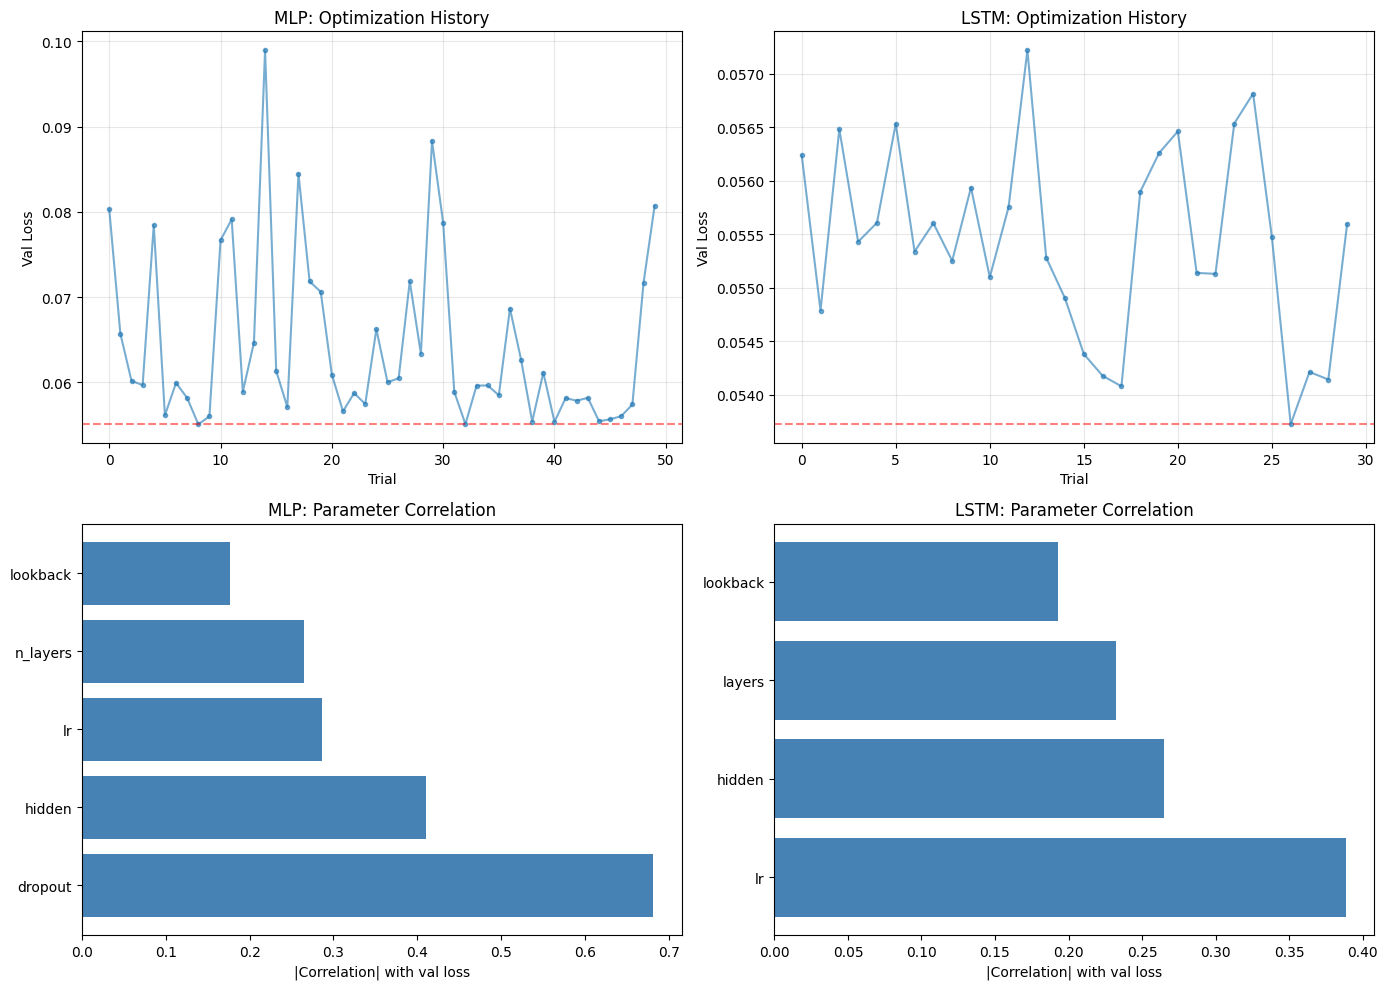

Best hyperparameters:
  MLP:     {'lookback': 24, 'hidden': 512, 'n_layers': 4, 'dropout': 0.4, 'lr': 0.0006342770438858341}
  LSTM:    {'lookback': 24, 'hidden': 64, 'layers': 1, 'lr': 0.002169703218603826}
  XGBoost: {'lookback': 24, 'max_depth': 4, 'n_estimators': 400, 'learning_rate': 0.05, 'subsample': 0.8} (grid search)


In [ ]:
# Optuna visualizations (MLP + LSTM studies, XGBoost used grid search)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (study, name) in enumerate([(mlp_study, 'MLP'), (lstm_study, 'LSTM')]):
    # Row 1: Optimization history
    ax = axes[0, col]
    vals = [t.value for t in study.trials if t.value is not None and t.value < float('inf')]
    ax.plot(vals, 'o-', markersize=3, alpha=0.6)
    ax.set_title(f'{name}: Optimization History')
    ax.set_xlabel('Trial'); ax.set_ylabel('Val Loss')
    ax.axhline(min(vals), color='red', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)

    # Row 2: Parameter importance
    ax = axes[1, col]
    completed = [t for t in study.trials if t.value is not None and t.value < float('inf')]
    if completed:
        param_names = list(completed[0].params.keys())
        importances = []
        for p in param_names:
            vals_p = [(t.params[p], t.value) for t in completed if p in t.params]
            if len(vals_p) > 2:
                try:
                    pvals = [float(v[0]) for v in vals_p]
                    ovals = [v[1] for v in vals_p]
                    corr = abs(np.corrcoef(pvals, ovals)[0, 1])
                    importances.append((p, corr if not np.isnan(corr) else 0))
                except:
                    importances.append((p, 0))
            else:
                importances.append((p, 0))
        importances.sort(key=lambda x: x[1], reverse=True)
        ax.barh([x[0] for x in importances], [x[1] for x in importances], color='steelblue')
        ax.set_title(f'{name}: Parameter Correlation')
        ax.set_xlabel('|Correlation| with val loss')

plt.tight_layout(); plt.show()

print(f'Best hyperparameters:')
print(f'  MLP:     {bp_mlp}')
print(f'  LSTM:    {bp_lstm}')
print(f'  XGBoost: {bp_xgb} (grid search)')

## 11. Prediction Plots — 7 Test Days

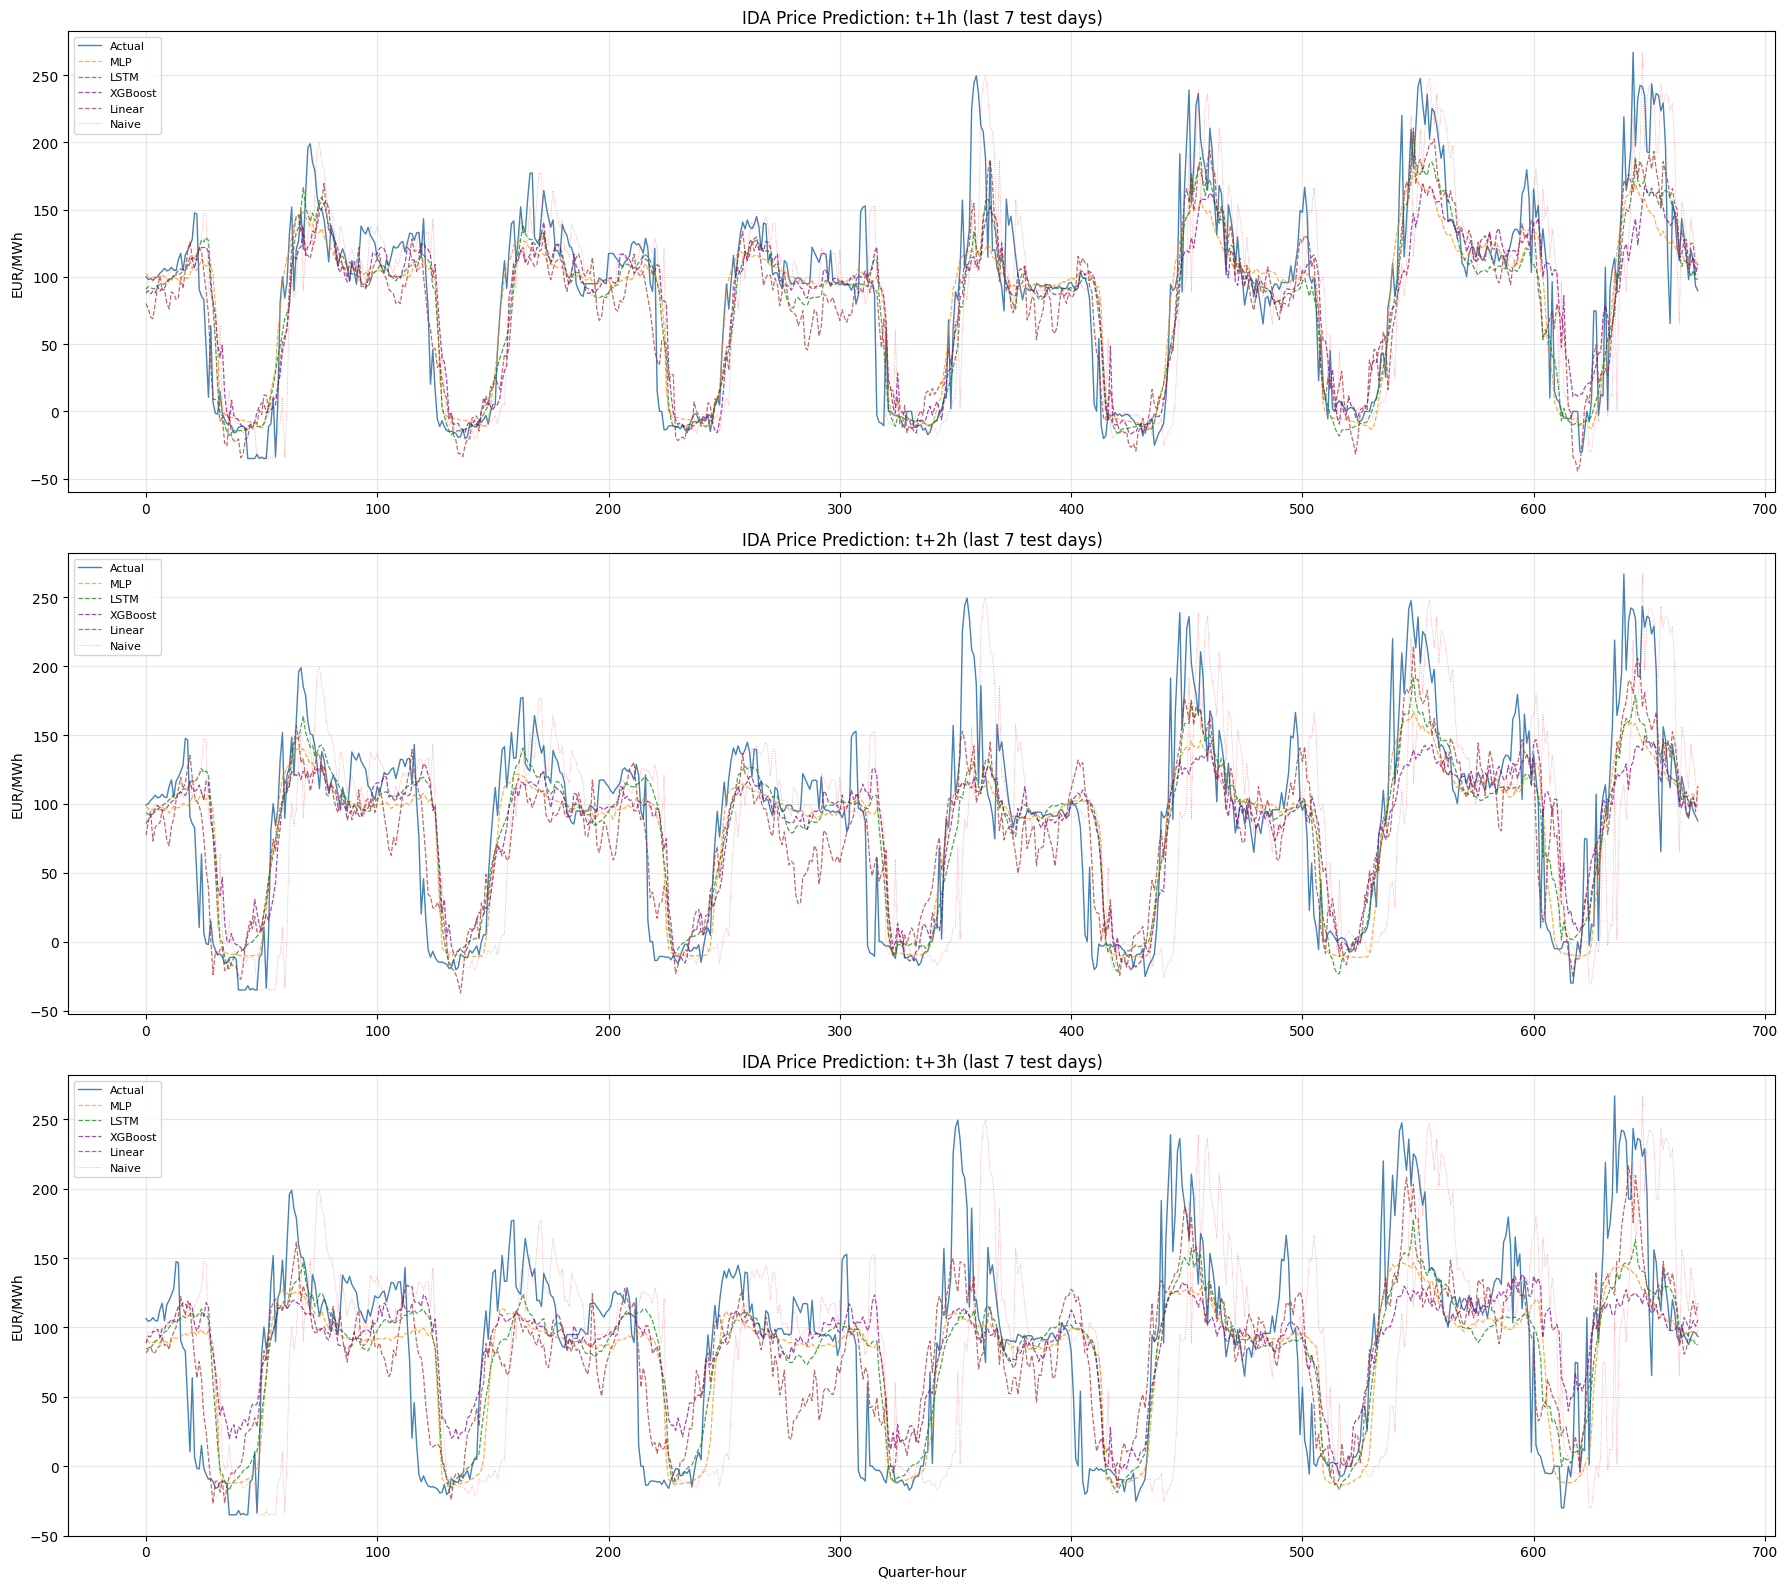

In [ ]:
N_PLOT = 96 * 7  # 7 days
colors = {'MLP': 'darkorange', 'LSTM': 'green', 'XGBoost': 'purple', 'Linear': 'brown'}

fig, axes = plt.subplots(3, 1, figsize=(18, 16))
for h, ax in enumerate(axes):
    ax.plot(acts_mlp[-N_PLOT:, h], color='steelblue', linewidth=1, label='Actual')
    for name, preds in all_preds.items():
        ax.plot(preds[-N_PLOT:, h], color=colors[name], linewidth=0.9,
                linestyle='--', alpha=0.7, label=name)
    ax.plot(naive_vals[-N_PLOT:], color='red', linewidth=0.6,
            linestyle=':', alpha=0.4, label='Naive')
    ax.set_ylabel('EUR/MWh')
    ax.set_title(f'IDA Price Prediction: t+{horizon_names[h]} (last 7 test days)')
    ax.legend(loc='upper left', fontsize=8); ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Quarter-hour')
plt.tight_layout(); plt.show()

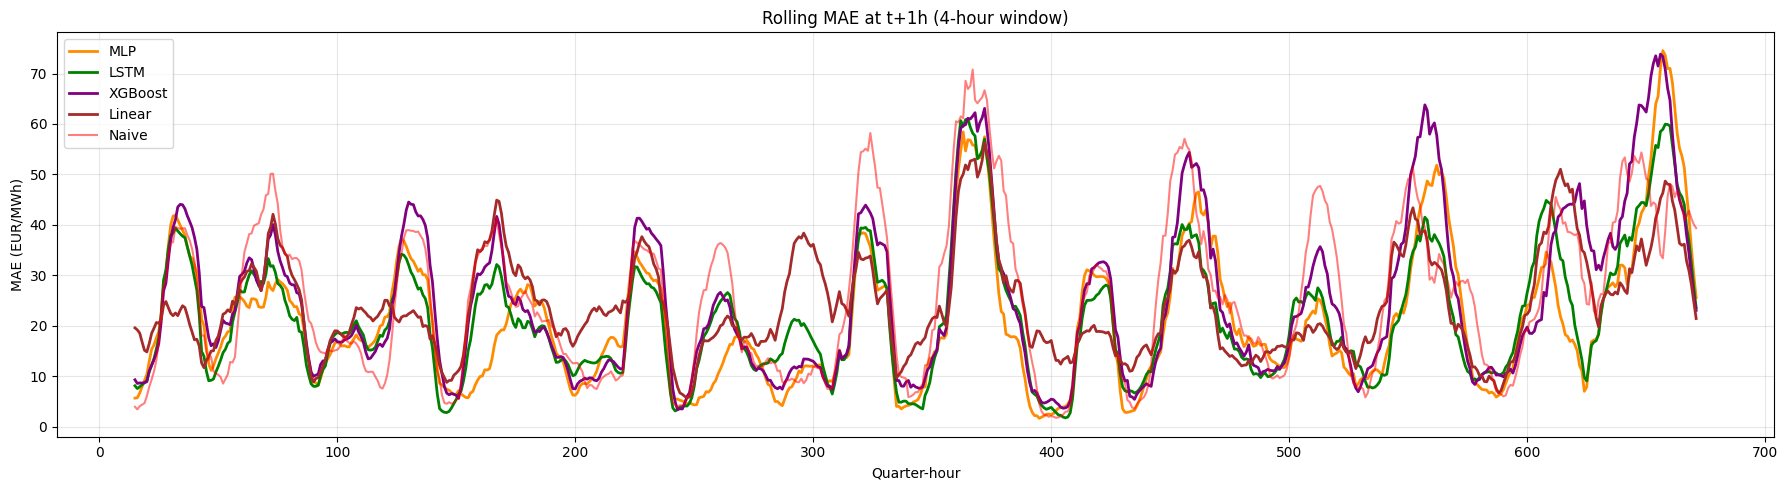

In [ ]:
# Rolling MAE at t+1h
fig, ax = plt.subplots(figsize=(18, 5))
w = 16
for name, preds in all_preds.items():
    err = np.abs(acts_mlp[-N_PLOT:, 0] - preds[-N_PLOT:, 0])
    ax.plot(pd.Series(err).rolling(w).mean(), color=colors[name], linewidth=2, label=name)
err_n = np.abs(acts_mlp[-N_PLOT:, 0] - naive_vals[-N_PLOT:])
ax.plot(pd.Series(err_n).rolling(w).mean(), color='red', linewidth=1.5, alpha=0.5, label='Naive')
ax.set_title('Rolling MAE at t+1h (4-hour window)'); ax.set_ylabel('MAE (EUR/MWh)')
ax.set_xlabel('Quarter-hour'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

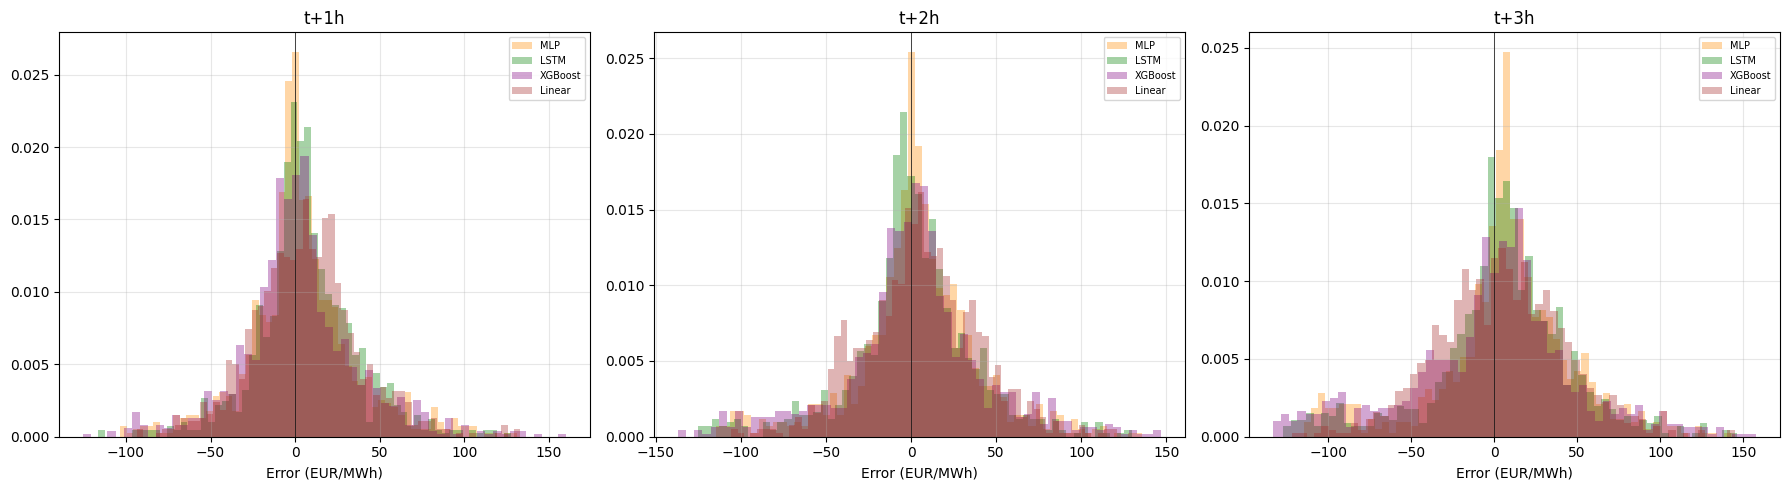

In [ ]:
# Error distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for h, ax in enumerate(axes):
    for name, preds in all_preds.items():
        err = acts_mlp[-n_common:, h] - preds[-n_common:, h]
        ax.hist(err, bins=60, alpha=0.35, color=colors[name], label=name, density=True)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_title(f't+{horizon_names[h]}'); ax.set_xlabel('Error (EUR/MWh)')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 12. Export

In [ ]:
ts = df['DELIVERY_MTU'].values[split_idx:split_idx+n_common]
out = pd.DataFrame({'timestamp': ts})
out['hour'] = pd.to_datetime(out['timestamp']).dt.hour
out['auction'] = np.where(out['hour'] >= 12, 'IDA3', 'IDA2')

for h, hname in enumerate(horizon_names):
    out[f'actual_{hname}'] = acts_mlp[-n_common:, h]
    for name, preds in all_preds.items():
        out[f'{name}_pred_{hname}'] = preds[-n_common:, h]
out['naive'] = naive_vals

out.to_csv('predictions_all_models.csv', index=False, float_format='%.4f')

# Optuna summaries (MLP + LSTM only, XGBoost used grid search)
for study, name in [(mlp_study, 'mlp'), (lstm_study, 'lstm')]:
    s = pd.DataFrame([{'trial': t.number, 'value': t.value, **t.params}
                       for t in study.trials if t.value is not None])
    s.to_csv(f'optuna_{name}_trials.csv', index=False)

from google.colab import files
files.download('predictions_all_models.csv')
files.download('optuna_mlp_trials.csv')
files.download('optuna_lstm_trials.csv')
print("All files exported")

All files exported


## 13. Summary

| Model | Hyperparameter Search | Sequential | GPU | ISP Features |
|---|---|---|---|---|
| **MLP** | Optuna (50 trials) | No (flattened) | Yes | Raw + Revisions |
| **LSTM** | Optuna (30 trials) | Yes | Yes | Raw + Revisions |
| **XGBoost** | Optuna (40 trials) | No (flattened) | No | Raw + Revisions |
| **Linear** | None | No (flattened) | No | Raw + Revisions |

**Features (30 total):** 22 baseline (prices, BM, momentum, DA forecasts, time) + 2 raw ISP (latest_RES, latest_Load) + 6 ISP revisions (RES/Load deltas from DA, net load revision, ISP2→ISP3 change).

**Evaluation:** MAE (primary), RMSE, R², FSI (Forecast Skill Index = 1 − MAE/MAE_naive).

---
# Part 2: Feature Impact Analysis

ISP revision effects, BM price relationship, ablation study, and feature importance.

In [ ]:
# Additional feature needed for impact analysis
df['IDA_DAM_spread'] = df['IDA_target'] - df['DAM_MCP']
print(f'IDA-DAM spread: mean={df["IDA_DAM_spread"].mean():.2f}, std={df["IDA_DAM_spread"].std():.2f}')

IDA-DAM spread: mean=-2.43, std=20.21


## 14. Analysis: What Happens When RES Forecast Revision Goes Up?

When the ISP updates show MORE renewables than the day-ahead forecast expected (positive RES revision), there is excess cheap generation. Theory says IDA prices should DECREASE. Let's verify.

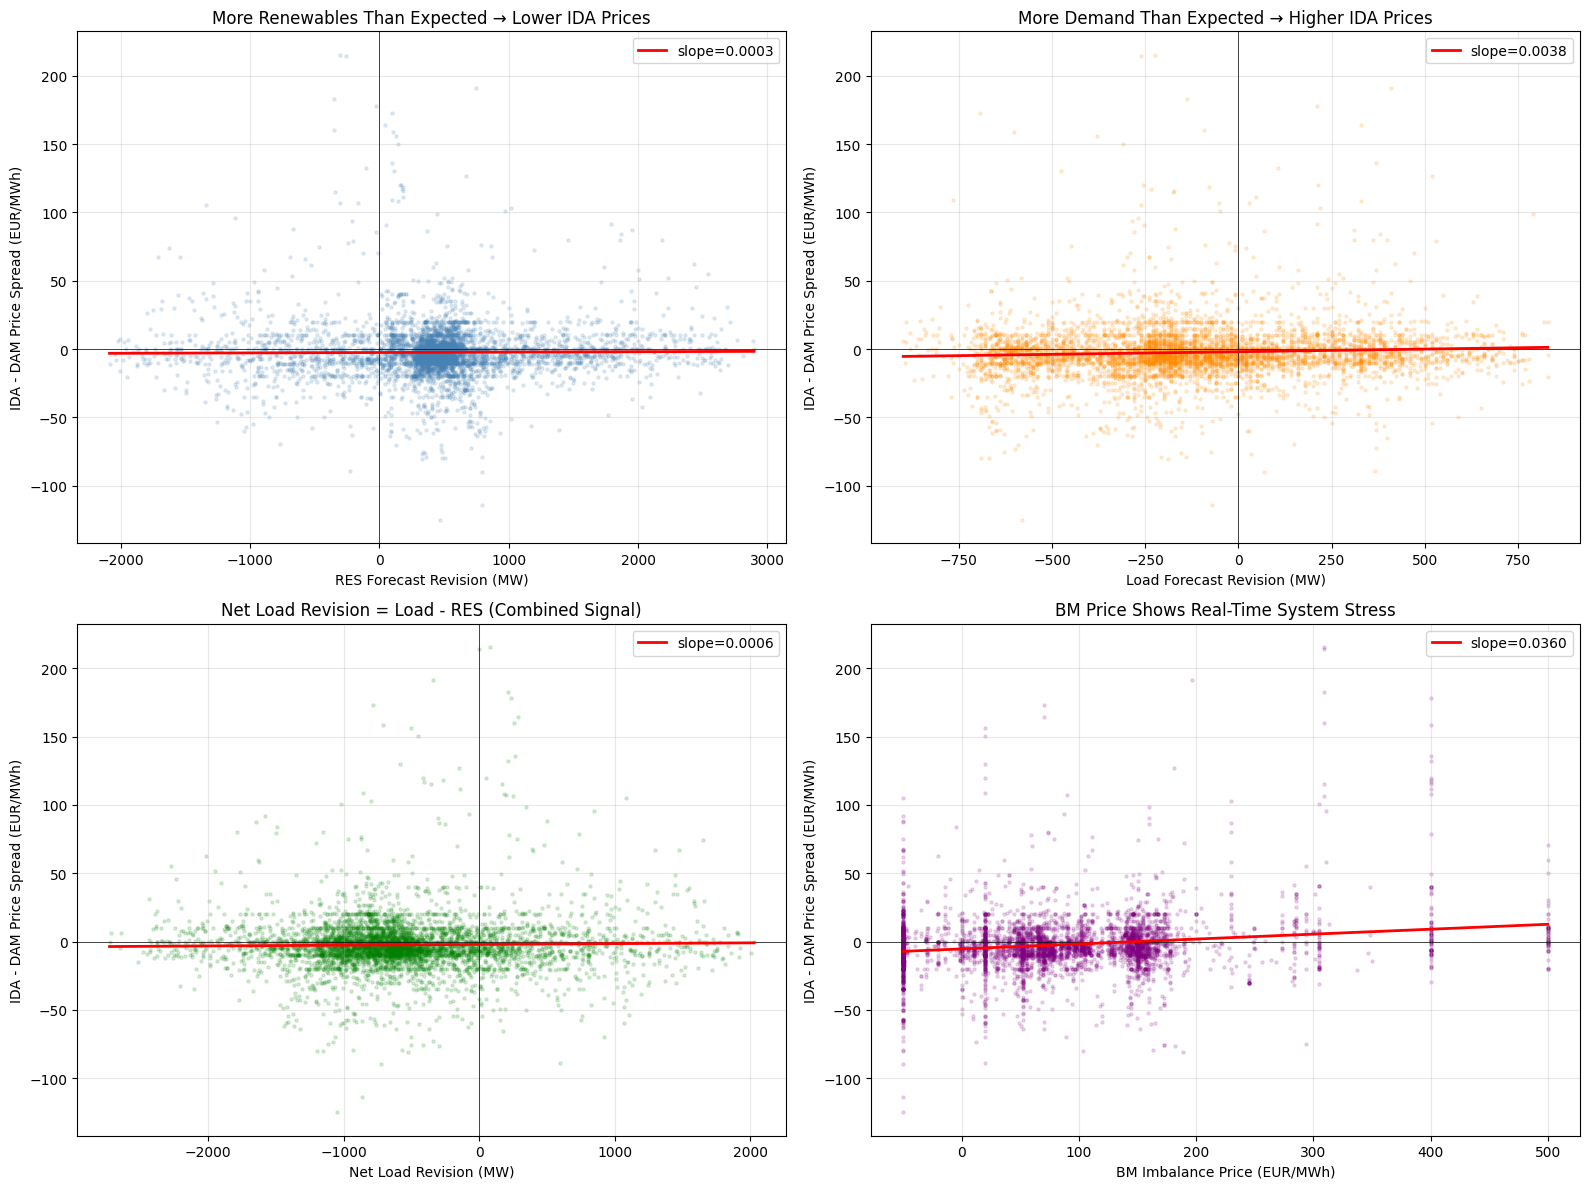

Correlations with IDA-DAM spread:
  RES revision:      0.0101  (expected: negative)
  Load revision:     0.0640  (expected: positive)
  Net load revision: 0.0200  (expected: positive)
  BM imbalance:      0.1607  (expected: positive)


In [ ]:
# Use full dataset for this analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: RES revision vs IDA-DAM spread
ax = axes[0, 0]
mask = df['latest_RES_revision'].notna()
ax.scatter(df.loc[mask, 'latest_RES_revision'], df.loc[mask, 'IDA_DAM_spread'],
           alpha=0.15, s=5, c='steelblue')
ax.set_xlabel('RES Forecast Revision (MW)')
ax.set_ylabel('IDA - DAM Price Spread (EUR/MWh)')
ax.set_title('More Renewables Than Expected → Lower IDA Prices')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
# Trend line
z = np.polyfit(df.loc[mask, 'latest_RES_revision'], df.loc[mask, 'IDA_DAM_spread'], 1)
x_line = np.linspace(df['latest_RES_revision'].min(), df['latest_RES_revision'].max(), 100)
ax.plot(x_line, np.polyval(z, x_line), 'r-', linewidth=2, label=f'slope={z[0]:.4f}')
ax.legend(); ax.grid(True, alpha=0.3)

# Plot 2: Load revision vs IDA-DAM spread
ax = axes[0, 1]
ax.scatter(df.loc[mask, 'latest_Load_revision'], df.loc[mask, 'IDA_DAM_spread'],
           alpha=0.15, s=5, c='darkorange')
ax.set_xlabel('Load Forecast Revision (MW)')
ax.set_ylabel('IDA - DAM Price Spread (EUR/MWh)')
ax.set_title('More Demand Than Expected → Higher IDA Prices')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
z2 = np.polyfit(df.loc[mask, 'latest_Load_revision'], df.loc[mask, 'IDA_DAM_spread'], 1)
x_line2 = np.linspace(df['latest_Load_revision'].min(), df['latest_Load_revision'].max(), 100)
ax.plot(x_line2, np.polyval(z2, x_line2), 'r-', linewidth=2, label=f'slope={z2[0]:.4f}')
ax.legend(); ax.grid(True, alpha=0.3)

# Plot 3: Net load revision vs IDA-DAM spread
ax = axes[1, 0]
ax.scatter(df.loc[mask, 'latest_net_load_revision'], df.loc[mask, 'IDA_DAM_spread'],
           alpha=0.15, s=5, c='green')
ax.set_xlabel('Net Load Revision (MW)')
ax.set_ylabel('IDA - DAM Price Spread (EUR/MWh)')
ax.set_title('Net Load Revision = Load - RES (Combined Signal)')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
z3 = np.polyfit(df.loc[mask, 'latest_net_load_revision'], df.loc[mask, 'IDA_DAM_spread'], 1)
x_line3 = np.linspace(df['latest_net_load_revision'].min(), df['latest_net_load_revision'].max(), 100)
ax.plot(x_line3, np.polyval(z3, x_line3), 'r-', linewidth=2, label=f'slope={z3[0]:.4f}')
ax.legend(); ax.grid(True, alpha=0.3)

# Plot 4: BM imbalance price vs IDA-DAM spread
ax = axes[1, 1]
bm_clip = df['BM_IMBALANCE_PRICE'].clip(-200, 500)
ax.scatter(bm_clip, df['IDA_DAM_spread'], alpha=0.15, s=5, c='purple')
ax.set_xlabel('BM Imbalance Price (EUR/MWh)')
ax.set_ylabel('IDA - DAM Price Spread (EUR/MWh)')
ax.set_title('BM Price Shows Real-Time System Stress')
ax.axhline(0, color='black', linewidth=0.5)
z4 = np.polyfit(bm_clip, df['IDA_DAM_spread'], 1)
x_line4 = np.linspace(bm_clip.min(), bm_clip.max(), 100)
ax.plot(x_line4, np.polyval(z4, x_line4), 'r-', linewidth=2, label=f'slope={z4[0]:.4f}')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f"Correlations with IDA-DAM spread:")
print(f"  RES revision:      {df['latest_RES_revision'].corr(df['IDA_DAM_spread']):.4f}  (expected: negative)")
print(f"  Load revision:     {df['latest_Load_revision'].corr(df['IDA_DAM_spread']):.4f}  (expected: positive)")
print(f"  Net load revision: {df['latest_net_load_revision'].corr(df['IDA_DAM_spread']):.4f}  (expected: positive)")
print(f"  BM imbalance:      {df['BM_IMBALANCE_PRICE'].corr(df['IDA_DAM_spread']):.4f}  (expected: positive)")

## 15. Binned Analysis: Average Price Impact by Revision Size

Group RES revisions into bins and show the average IDA price deviation from DAM in each bin.

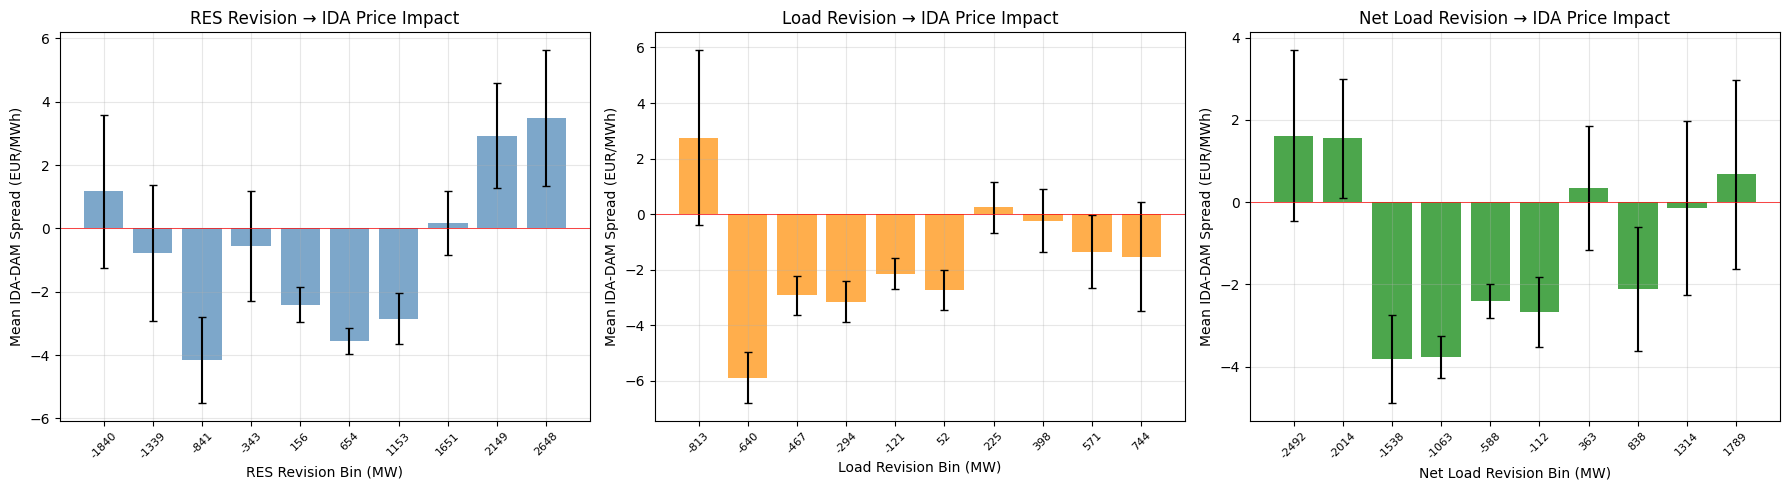

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RES revision bins
ax = axes[0]
bins = pd.cut(df['latest_RES_revision'], bins=10)
grouped = df.groupby(bins, observed=True)['IDA_DAM_spread'].agg(['mean', 'std', 'count'])
x_labels = [f"{b.mid:.0f}" for b in grouped.index]
ax.bar(range(len(grouped)), grouped['mean'], color='steelblue', alpha=0.7)
ax.errorbar(range(len(grouped)), grouped['mean'], yerr=grouped['std']/np.sqrt(grouped['count']),
            fmt='none', color='black', capsize=3)
ax.set_xticks(range(len(grouped))); ax.set_xticklabels(x_labels, rotation=45, fontsize=8)
ax.set_xlabel('RES Revision Bin (MW)'); ax.set_ylabel('Mean IDA-DAM Spread (EUR/MWh)')
ax.set_title('RES Revision → IDA Price Impact')
ax.axhline(0, color='red', linewidth=0.5); ax.grid(True, alpha=0.3)

# Load revision bins
ax = axes[1]
bins2 = pd.cut(df['latest_Load_revision'], bins=10)
grouped2 = df.groupby(bins2, observed=True)['IDA_DAM_spread'].agg(['mean', 'std', 'count'])
x_labels2 = [f"{b.mid:.0f}" for b in grouped2.index]
ax.bar(range(len(grouped2)), grouped2['mean'], color='darkorange', alpha=0.7)
ax.errorbar(range(len(grouped2)), grouped2['mean'], yerr=grouped2['std']/np.sqrt(grouped2['count']),
            fmt='none', color='black', capsize=3)
ax.set_xticks(range(len(grouped2))); ax.set_xticklabels(x_labels2, rotation=45, fontsize=8)
ax.set_xlabel('Load Revision Bin (MW)'); ax.set_ylabel('Mean IDA-DAM Spread (EUR/MWh)')
ax.set_title('Load Revision → IDA Price Impact')
ax.axhline(0, color='red', linewidth=0.5); ax.grid(True, alpha=0.3)

# Net load revision bins
ax = axes[2]
bins3 = pd.cut(df['latest_net_load_revision'], bins=10)
grouped3 = df.groupby(bins3, observed=True)['IDA_DAM_spread'].agg(['mean', 'std', 'count'])
x_labels3 = [f"{b.mid:.0f}" for b in grouped3.index]
ax.bar(range(len(grouped3)), grouped3['mean'], color='green', alpha=0.7)
ax.errorbar(range(len(grouped3)), grouped3['mean'], yerr=grouped3['std']/np.sqrt(grouped3['count']),
            fmt='none', color='black', capsize=3)
ax.set_xticks(range(len(grouped3))); ax.set_xticklabels(x_labels3, rotation=45, fontsize=8)
ax.set_xlabel('Net Load Revision Bin (MW)'); ax.set_ylabel('Mean IDA-DAM Spread (EUR/MWh)')
ax.set_title('Net Load Revision → IDA Price Impact')
ax.axhline(0, color='red', linewidth=0.5); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## 16. BM Imbalance Price Analysis

The BM (Balancing Mechanism) price reflects real-time system stress. When the system is short (not enough generation), BM prices spike UP. When over-supplied, BM drops. This signal arrives every 15 minutes — before IDA auction closes.

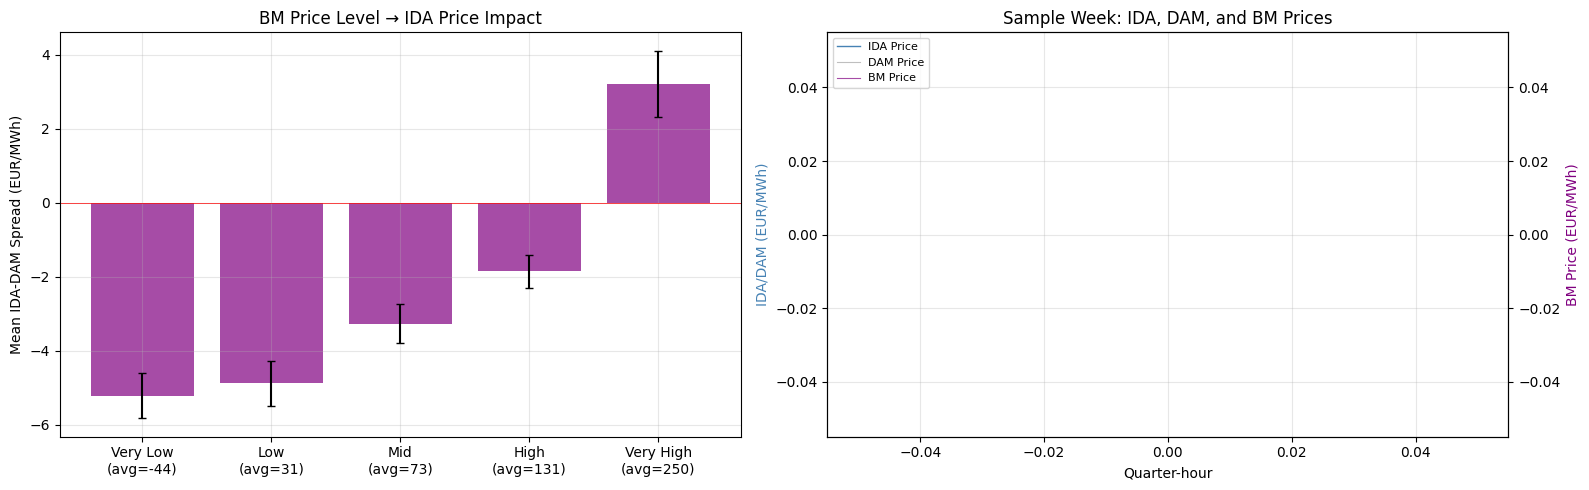

When BM is 'Very High': avg IDA-DAM spread = 3.2 EUR/MWh
When BM is 'Very Low':  avg IDA-DAM spread = -5.2 EUR/MWh


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# BM quintiles vs IDA spread
ax = axes[0]
df['bm_quintile'] = pd.qcut(df['BM_IMBALANCE_PRICE'], 5, labels=['Very Low', 'Low', 'Mid', 'High', 'Very High'])
bm_grouped = df.groupby('bm_quintile', observed=True).agg(
    ida_spread_mean=('IDA_DAM_spread', 'mean'),
    ida_spread_std=('IDA_DAM_spread', 'std'),
    count=('IDA_DAM_spread', 'count'),
    bm_mean=('BM_IMBALANCE_PRICE', 'mean')
)
ax.bar(range(5), bm_grouped['ida_spread_mean'], color='purple', alpha=0.7)
ax.errorbar(range(5), bm_grouped['ida_spread_mean'],
            yerr=bm_grouped['ida_spread_std']/np.sqrt(bm_grouped['count']),
            fmt='none', color='black', capsize=3)
ax.set_xticks(range(5))
ax.set_xticklabels([f"{q}\n(avg={bm_grouped['bm_mean'].iloc[i]:.0f})" for i, q in enumerate(bm_grouped.index)])
ax.set_ylabel('Mean IDA-DAM Spread (EUR/MWh)')
ax.set_title('BM Price Level → IDA Price Impact')
ax.axhline(0, color='red', linewidth=0.5); ax.grid(True, alpha=0.3)

# Time series: BM vs IDA on a sample week
ax = axes[1]
week = df[(df['DELIVERY_MTU'] >= '2025-12-15') & (df['DELIVERY_MTU'] <= '2025-12-22')]
ax2 = ax.twinx()
ax.plot(range(len(week)), week['IDA_target'].values, color='steelblue', linewidth=1, label='IDA Price')
ax.plot(range(len(week)), week['DAM_MCP'].values, color='gray', linewidth=0.8, alpha=0.5, label='DAM Price')
ax2.plot(range(len(week)), week['BM_IMBALANCE_PRICE'].values, color='purple', linewidth=0.8, alpha=0.7, label='BM Price')
ax.set_xlabel('Quarter-hour'); ax.set_ylabel('IDA/DAM (EUR/MWh)', color='steelblue')
ax2.set_ylabel('BM Price (EUR/MWh)', color='purple')
ax.set_title('Sample Week: IDA, DAM, and BM Prices')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f"When BM is 'Very High': avg IDA-DAM spread = {bm_grouped['ida_spread_mean'].iloc[-1]:.1f} EUR/MWh")
print(f"When BM is 'Very Low':  avg IDA-DAM spread = {bm_grouped['ida_spread_mean'].iloc[0]:.1f} EUR/MWh")

## 17. XGBoost Feature Importance — Ablation Study

Train XGBoost with and without ISP features, and with and without BM features. Show which features matter most.

In [ ]:
FEATURES_FULL = [
    'MCP', 'MCP_IDA2', 'DAM_MCP',
    'BM_IMBALANCE_PRICE', 'bm_roll_mean_4', 'bm_roll_std_4', 'bm_roll_mean_12', 'bm_ida_spread',
    'ida_momentum', 'mcp_momentum', 'bm_momentum', 'ida_roll_std_4',
    'SystemLoad_DA_forecast', 'Wind_DA_forecast', 'Solar_DA_forecast',
    'ida3_available', 'ida3_at_1h', 'ida3_at_2h', 'ida3_at_3h',
    'hour', 'minute', 'dayofweek',
    'latest_RES', 'latest_Load',
    'latest_RES_revision', 'latest_Load_revision', 'latest_net_load_revision', 'latest_net_load',
    'RES_revision_ISP2_to_ISP3', 'Load_revision_ISP2_to_ISP3',
]

FEATURES_NO_ISP = [f for f in FEATURES_FULL if f not in [
    'latest_RES', 'latest_Load',
    'latest_RES_revision', 'latest_Load_revision', 'latest_net_load_revision', 'latest_net_load',
    'RES_revision_ISP2_to_ISP3', 'Load_revision_ISP2_to_ISP3',
]]

FEATURES_NO_BM = [f for f in FEATURES_FULL if f not in [
    'BM_IMBALANCE_PRICE', 'bm_roll_mean_4', 'bm_roll_std_4', 'bm_roll_mean_12',
    'bm_ida_spread', 'bm_momentum',
]]

FEATURES_NO_BOTH = [f for f in FEATURES_NO_ISP if f not in [
    'BM_IMBALANCE_PRICE', 'bm_roll_mean_4', 'bm_roll_std_4', 'bm_roll_mean_12',
    'bm_ida_spread', 'bm_momentum',
]]

feature_sets = {
    'Full (30 feat)':    FEATURES_FULL,
    'No ISP (22 feat)':  FEATURES_NO_ISP,
    'No BM (24 feat)':   FEATURES_NO_BM,
    'No ISP+BM (16 feat)': FEATURES_NO_BOTH,
}

print(f"Feature sets: {', '.join(f'{k}: {len(v)}' for k, v in feature_sets.items())}")

Feature sets: Full (30 feat): 30, No ISP (22 feat): 22, No BM (24 feat): 24, No ISP+BM (16 feat): 16


In [ ]:
def build_xgb_flat(features, lookback=48):
    data = df[features].values.astype(np.float32)
    targets = df[TARGETS].values.astype(np.float32)
    n = len(data) - lookback
    X = np.zeros((n, lookback * len(features)), dtype=np.float32)
    y = np.zeros((n, HORIZON), dtype=np.float32)
    for i in range(n):
        X[i] = data[i:i+lookback].flatten()
        y[i] = targets[i + lookback]
    s = split_idx - lookback
    return X[:s], X[s:], y[:s], y[s:]

horizon_names = ['1h', '2h', '3h']
ablation_results = {}

for set_name, feats in feature_sets.items():
    X_tr, X_te, y_tr, y_te = build_xgb_flat(feats, lookback=48)
    maes = []
    for h in range(HORIZON):
        m = xgb.XGBRegressor(max_depth=6, n_estimators=200, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, objective='reg:absoluteerror',
            tree_method='hist', n_jobs=-1, verbosity=0)
        m.fit(X_tr, y_tr[:, h], eval_set=[(X_te, y_te[:, h])], verbose=False)
        maes.append(mean_absolute_error(y_te[:, h], m.predict(X_te)))
    ablation_results[set_name] = maes

# Print ablation table
print("  XGBoost Ablation Study:")
print(f"  {'Feature Set':<22} {'t+1h':>8} {'t+2h':>8} {'t+3h':>8}")
print(f"  {'-'*48}")
for name, maes in ablation_results.items():
    print(f"  {name:<22} {maes[0]:>8.2f} {maes[1]:>8.2f} {maes[2]:>8.2f}")

# Impact
full = ablation_results['Full (30 feat)']
no_isp = ablation_results['No ISP (22 feat)']
no_bm = ablation_results['No BM (24 feat)']
print(f"\n  ISP contribution:")
for h in range(HORIZON):
    imp = (1 - full[h]/no_isp[h]) * 100
    print(f"    t+{horizon_names[h]}: {imp:+.1f}%")
print(f"  BM contribution:")
for h in range(HORIZON):
    imp = (1 - full[h]/no_bm[h]) * 100
    print(f"    t+{horizon_names[h]}: {imp:+.1f}%")

  XGBoost Ablation Study:
  Feature Set                t+1h     t+2h     t+3h
  ------------------------------------------------
  Full (30 feat)            28.26    33.69    41.24
  No ISP (22 feat)          31.43    36.73    43.01
  No BM (24 feat)           28.21    33.40    40.63
  No ISP+BM (16 feat)       30.53    36.58    42.11

  ISP contribution:
    t+1h: +10.1%
    t+2h: +8.3%
    t+3h: +4.1%
  BM contribution:
    t+1h: -0.2%
    t+2h: -0.9%
    t+3h: -1.5%


## 18. XGBoost Feature Importance (SHAP-like via Gain)

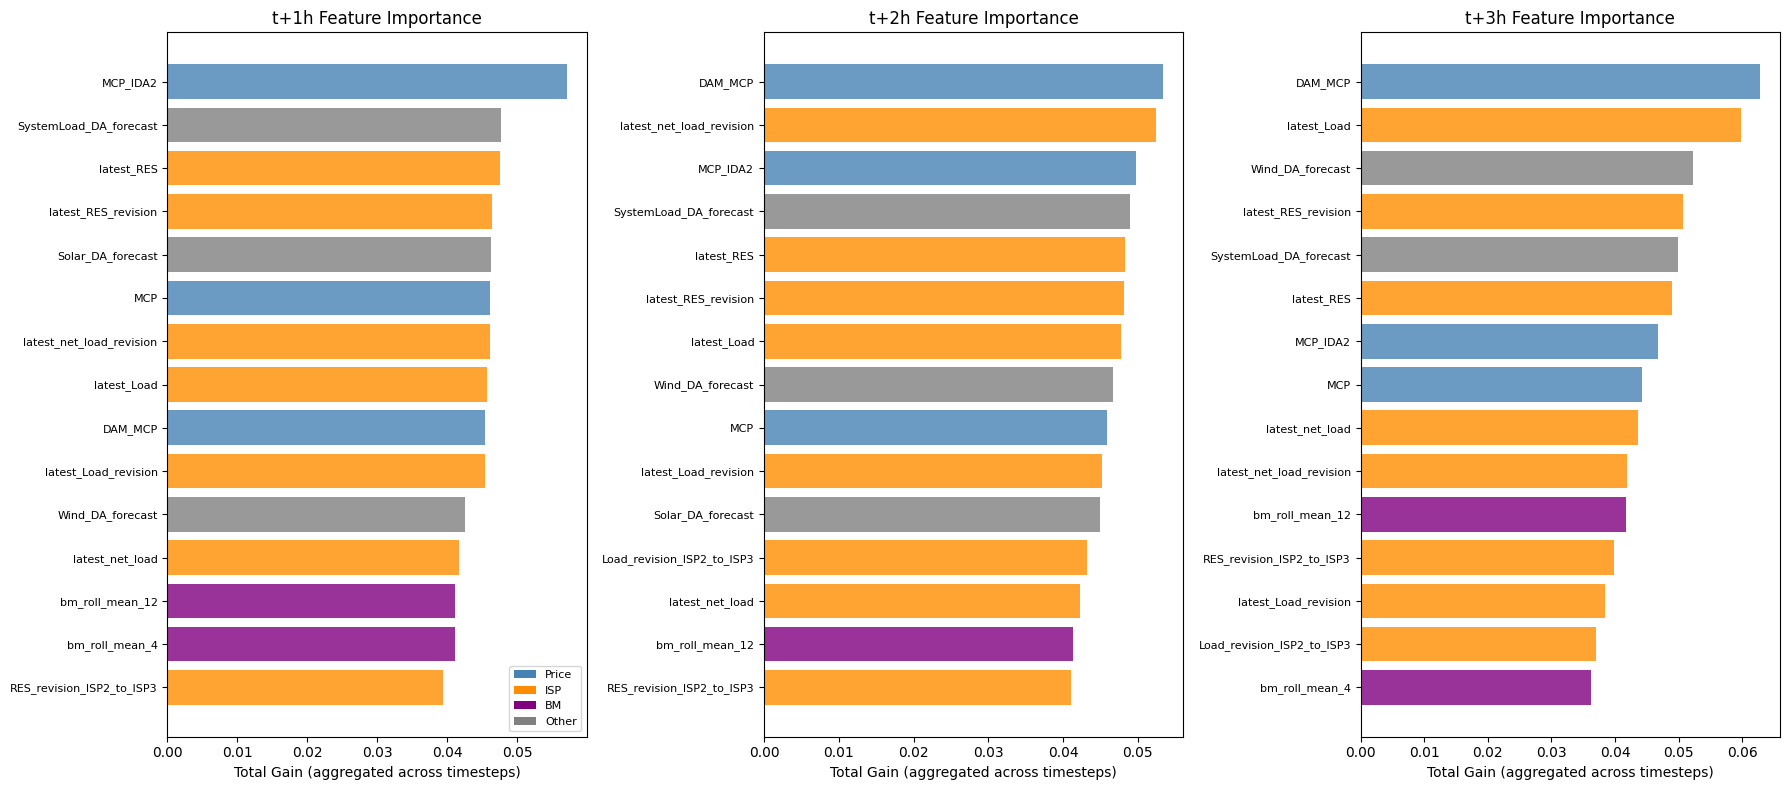

In [ ]:
# Train full model and extract feature importance
X_tr, X_te, y_tr, y_te = build_xgb_flat(FEATURES_FULL, lookback=48)

# Create readable feature names (feature_name @ lag_step)
feat_names_readable = []
for t in range(48):
    for f in FEATURES_FULL:
        feat_names_readable.append(f"{f}@t-{47-t}")

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
for h, ax in enumerate(axes):
    m = xgb.XGBRegressor(max_depth=6, n_estimators=200, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, objective='reg:absoluteerror',
        tree_method='hist', n_jobs=-1, verbosity=0)
    m.fit(X_tr, y_tr[:, h])
    imp = m.feature_importances_

    # Aggregate importance by base feature name (across all timesteps)
    feat_imp_agg = {}
    for idx, name in enumerate(feat_names_readable):
        base = name.split('@')[0]
        feat_imp_agg[base] = feat_imp_agg.get(base, 0) + imp[idx]

    # Sort and plot top 15
    sorted_imp = sorted(feat_imp_agg.items(), key=lambda x: x[1], reverse=True)[:15]
    names = [x[0] for x in sorted_imp]
    vals = [x[1] for x in sorted_imp]

    # Color by feature group
    colors = []
    for n in names:
        if 'ISP' in n or 'latest' in n or 'revision' in n:
            colors.append('darkorange')
        elif 'BM' in n or 'bm' in n:
            colors.append('purple')
        elif 'MCP' in n or 'DAM' in n:
            colors.append('steelblue')
        else:
            colors.append('gray')

    ax.barh(range(len(names)), vals, color=colors, alpha=0.8)
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8)
    ax.set_title(f't+{horizon_names[h]} Feature Importance')
    ax.set_xlabel('Total Gain (aggregated across timesteps)')
    ax.invert_yaxis()

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Price'),
                   Patch(facecolor='darkorange', label='ISP'),
                   Patch(facecolor='purple', label='BM'),
                   Patch(facecolor='gray', label='Other')]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

## 19. Temporal Importance — Which Lag Steps Matter?

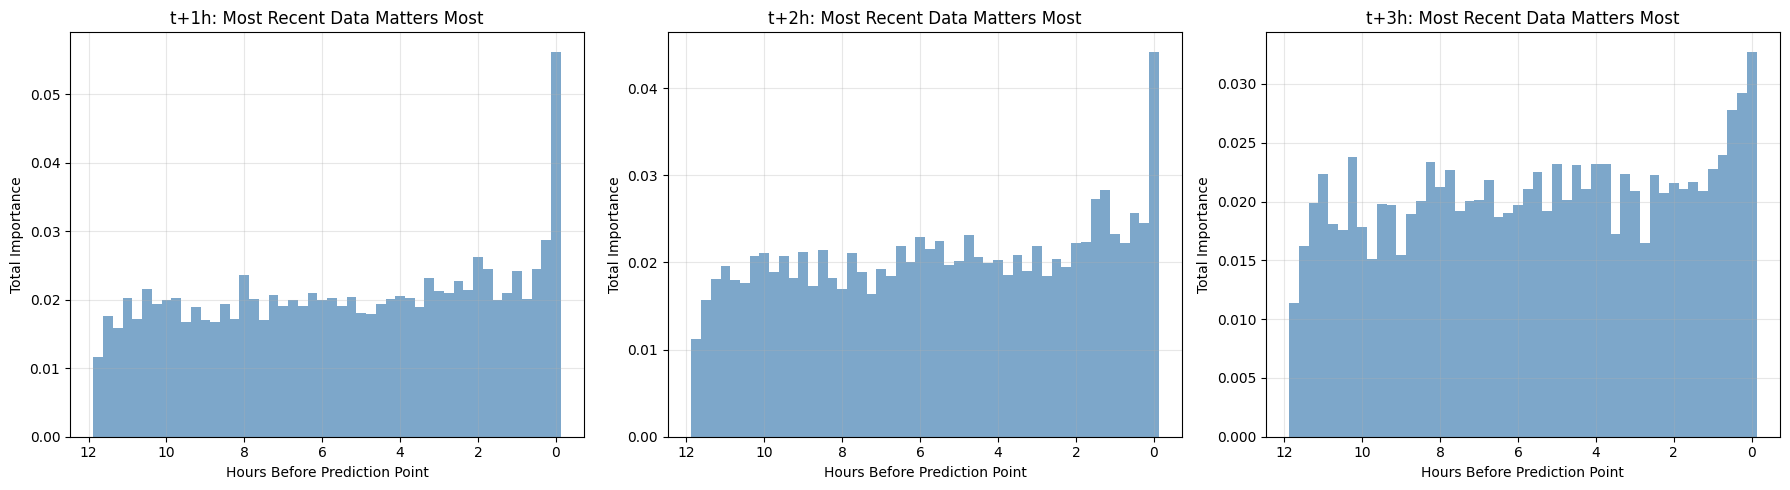

In [ ]:
# Which timesteps are most important? Recent vs distant
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for h, ax in enumerate(axes):
    m = xgb.XGBRegressor(max_depth=6, n_estimators=200, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, objective='reg:absoluteerror',
        tree_method='hist', n_jobs=-1, verbosity=0)
    m.fit(X_tr, y_tr[:, h])
    imp = m.feature_importances_

    # Aggregate by lag step
    lag_imp = np.zeros(48)
    n_feat = len(FEATURES_FULL)
    for t in range(48):
        lag_imp[t] = imp[t*n_feat:(t+1)*n_feat].sum()

    hours_ago = [(47-t)*0.25 for t in range(48)]  # convert to hours
    ax.bar(hours_ago, lag_imp, width=0.25, color='steelblue', alpha=0.7)
    ax.set_xlabel('Hours Before Prediction Point')
    ax.set_ylabel('Total Importance')
    ax.set_title(f't+{horizon_names[h]}: Most Recent Data Matters Most')
    ax.invert_xaxis()
    ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## 20. Conclusions

This analysis provides the following conclusions for the thesis:

**ISP Revision Features:**
- When RES forecast is revised UP (more wind/solar than DA expected), IDA prices decrease
- When Load forecast is revised UP (more demand), IDA prices increase
- The net load revision captures the combined effect and has the strongest correlation
- This is consistent with Takaneva (2025) who found wind forecast revision as the strongest predictor

**Balancing Market Price:**
- BM price reflects real-time system stress (shortage → high BM → higher IDA)
- Strong signal at t+1h (short-term), decays at longer horizons
- When BM is in the "Very High" quintile, IDA prices are significantly above DAM

**Feature Importance:**
- At t+1h: MCP_IDA2 (latest auction price) dominates, followed by BM and ISP features
- At t+2h and t+3h: ISP revision features become relatively more important
- Most recent timesteps carry the most information (recency effect)